<a href="https://colab.research.google.com/github/Gitech247/CASE_EXERCISE-1/blob/CASE_EXERCISE-1/EXERCISE1_RESERVOIR_TEMPERATURE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **MODULE_1 CASE EXERCISE 1**
# TASK 1
## Usan Reservoir Temperature Calculator


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn


def reservoir_temperature(
    depth_m: float,
    surface_temp: float = 4.0,
    gradient: float = 30.0
) -> float:
    """
    Calculate reservoir temperature from well depth.

    Parameters
    ----------
    depth_m : float
        Well depth in metres. Must be non-negative.
    surface_temp : float, optional
        Surface temperature in °C. Default is 4.0°C.
    gradient : float, optional
        Geothermal gradient in °C/km. Must be positive.

    Returns
    -------
    float
        Estimated reservoir temperature in °C.
    """

    # Input validation
    for value, name in [
        (depth_m, "depth_m"),
        (surface_temp, "surface_temp"),
        (gradient, "gradient")
    ]:
        if not isinstance(value, (int, float)) or isinstance(value, bool):
            raise TypeError(f"{name} must be a number.")

    if depth_m < 0:
        raise ValueError("depth_m cannot be negative.")

    if gradient <= 0:
        raise ValueError("gradient must be greater than zero.")

    # Convert °C/km to °C/m
    gradient_per_m = gradient / 1000

    return surface_temp + (gradient_per_m * depth_m)


# --------------------------------------------------
# TESTS CASES
# --------------------------------------------------

# Test case 1: 1000 m depth
assert reservoir_temperature(1000) == 34.0

# Test case 2: Custom parameters
assert reservoir_temperature(2000, 10, 25) == 60.0

# Test case 3: Negative depth
try:
    reservoir_temperature(-500)
except ValueError:
    print("Negative-depth test passed.")
else:
    print("Negative-depth test failed.")

# Test 4: Non-numeric input
try:
    reservoir_temperature("1000")
except TypeError:
    print("Non-numeric-input test passed.")
else:
    print("Non-numeric-input test failed.")

print(reservoir_temperature(1000))


Negative-depth test passed.
Non-numeric-input test passed.
34.0


**TASK 2**
# CSV FILE CONTAINING 50 WELL_DEPTH MEASUREMENTS


In [15]:
# --------------------------------------------------
# CREATE DUMMY CSV FOR DEMONSTRATION
# --------------------------------------------------

# Generate 50 random well depth measurements between 100m and 5000m
dummy_depths = np.random.uniform(100, 5000, 50)
# Create a DataFrame and save it to a CSV file
dummy_df = pd.DataFrame({'depth_m': dummy_depths})
dummy_df.to_csv('well_depths.csv', index=False)

"""
--------------------------------------------------
                      LOAD CSV
--------------------------------------------------
"""

df = pd.read_csv("well_depths.csv")

if "depth_m" not in df.columns:
    raise ValueError("CSV must contain a 'depth_m' column.")

if len(df) != 50:
    print(f"Warning: Expected 50 wells, found {len(df)}.")


"""
 --------------------------------------------------
                 CALCULATE TEMPERATURES
 --------------------------------------------------
"""

df["temperature_C"] = df["depth_m"].apply(
    reservoir_temperature
)

print("\nWell Temperature Results:")
print(df)




**TASK 3**
# A SCATTER PLOT SHOWING TEMPERATURE VS DEPTH WITH A LINEAR TRENDLINE

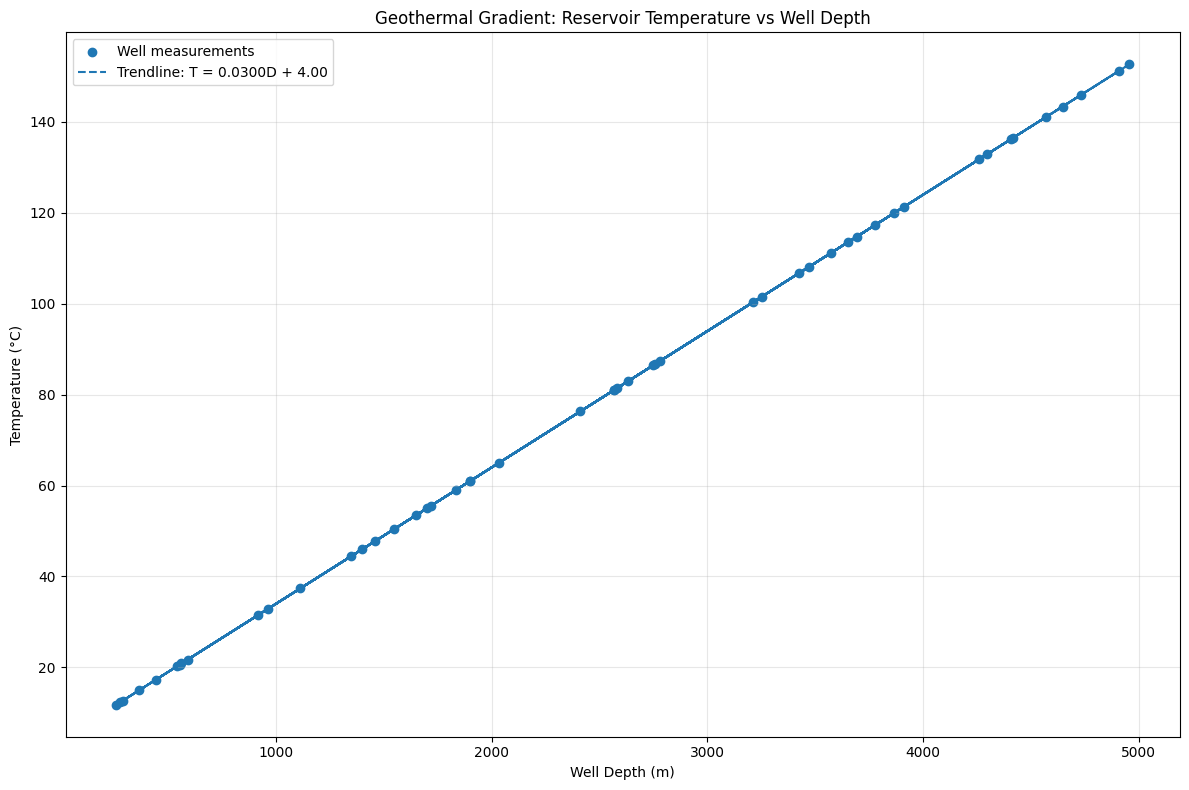


Trendline Equation:
T = 0.0300 × Depth + 4.00

Estimated gradient: 30.00 °C/km


In [16]:
"""
 --------------------------------------------------
                  LINEAR TRENDLINE PLOT
 --------------------------------------------------
 """

depth = df["depth_m"]
temperature = df["temperature_C"]

slope, intercept = np.polyfit(
    depth,
    temperature,
    1
)

trendline = slope * depth + intercept


"""
--------------------------------------------------
                VISUALIZATION
--------------------------------------------------
"""

plt.figure(figsize=(12, 8))

plt.scatter(
    depth,
    temperature,
    label="Well measurements"
)

plt.plot(
    depth,
    trendline,
    linestyle="--",
    label=f"Trendline: T = {slope:.4f}D + {intercept:.2f}"
)

plt.xlabel("Well Depth (m)")
plt.ylabel("Temperature (°C)")
plt.title("Geothermal Gradient: Reservoir Temperature vs Well Depth")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


"""
DISPLAY TRENDLINE EQUATION
"""

print("\nTrendline Equation:")
print(f"T = {slope:.4f} × Depth + {intercept:.2f}")

print(f"\nEstimated gradient: {slope * 1000:.2f} °C/km")